In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import keras

In [2]:
def preprocess_image(img):
    img = cv2.resize(img, (28, 28))
    img = 255 - img            # invert (MNIST style)
    img = img.astype("float32") / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img


In [3]:
def contrastive_loss(y_true, y_pred):
    margin = 1.0
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

In [4]:
query_img = cv2.imread("/content/og7.png", cv2.IMREAD_GRAYSCALE)
query_img = preprocess_image(query_img)


In [8]:
support_paths = [
    "/content/img7.png",
    "/content/img8.jpg",  # Corrected from .jpeg to .jpg
    "/content/og7.png",
    "/content/img5.jpg"   # Corrected from .jpeg to .jpg
]

support_imgs = []

for path in support_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: # Check if image loading failed
        print(f"Warning: Could not load image from {path}. Skipping this image.")
        continue # Skip to the next image
    img = preprocess_image(img)
    support_imgs.append(img)

# Ensure support_imgs is not empty before trying to stack them
if not support_imgs:
    print("Error: No support images were loaded successfully. Cannot create np.vstack.")
else:
    support_imgs = np.vstack(support_imgs)

In [9]:
query_batch = np.repeat(query_img, 4, axis=0)


In [10]:
model_path = "/content/model1.keras"

model3 = keras.models.load_model(
    model_path,
    custom_objects={"contrastive_loss": contrastive_loss}
)


In [11]:
model_path = "/content/model2.keras"

model2 = keras.models.load_model(
    model_path,
    custom_objects={"contrastive_loss": contrastive_loss}
)


In [14]:
distances = model2.predict(
    [query_batch, support_imgs],
    verbose=0
).flatten()

print("Distances:", distances)


Distances: [2.2757353e-05 2.2653892e-05 2.2787586e-05 2.2486975e-05]


In [15]:
best_match = np.argmin(distances)

print("Best match index:", best_match)
##print("Predicted label:", y_test[best_match])
print("Distance:", distances[best_match])


Best match index: 3
Distance: 2.2486975e-05


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-calculate distances for model2
distances_model2 = model2.predict(
    [query_batch, support_imgs],
    verbose=0
).flatten()
print("Distances (Model 2):")
print(distances_model2)

# Re-calculate distances for model3
distances_model3 = model3.predict(
    [query_batch, support_imgs],
    verbose=0
).flatten()
print("\nDistances (Model 3):")
print(distances_model3)

Distances (Model 2):
[2.2757353e-05 2.2653892e-05 2.2787586e-05 2.2486975e-05]

Distances (Model 3):
[0.33424637 0.333913   0.3346458  0.33336988]


In [17]:
# Create a DataFrame for plotting
data = {
    'Model': ['Model 2'] * len(distances_model2) + ['Model 3'] * len(distances_model3),
    'Support Image Index': list(range(len(distances_model2))) * 2,
    'Distance': np.concatenate([distances_model2, distances_model3])
}
df_distances = pd.DataFrame(data)

# Display the DataFrame head for review
print(df_distances.head())

     Model  Support Image Index  Distance
0  Model 2                    0  0.000023
1  Model 2                    1  0.000023
2  Model 2                    2  0.000023
3  Model 2                    3  0.000022
4  Model 3                    0  0.334246


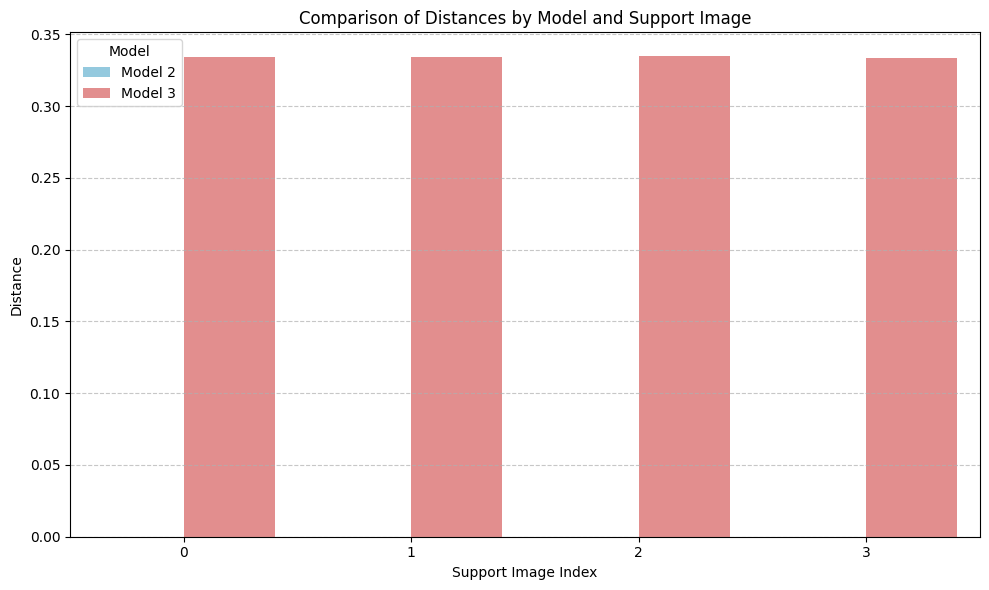

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_distances,
    x='Support Image Index',
    y='Distance',
    hue='Model',
    palette={'Model 2': 'skyblue', 'Model 3': 'lightcoral'}
)
plt.title('Comparison of Distances by Model and Support Image')
plt.xlabel('Support Image Index')
plt.ylabel('Distance')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# Also print descriptive statistics for each model's distances
print("\nDescriptive Statistics for Model 2 Distances:")
print(pd.Series(distances_model2).describe())

print("\nDescriptive Statistics for Model 3 Distances:")
print(pd.Series(distances_model3).describe())


Descriptive Statistics for Model 2 Distances:
count    4.000000e+00
mean     2.267145e-05
std      1.356544e-07
min      2.248697e-05
25%      2.261216e-05
50%      2.270562e-05
75%      2.276491e-05
max      2.278759e-05
dtype: float64

Descriptive Statistics for Model 3 Distances:
count    4.000000
mean     0.334044
std      0.000540
min      0.333370
25%      0.333777
50%      0.334080
75%      0.334346
max      0.334646
dtype: float64


In [12]:
distances = model3.predict(
    [query_batch, support_imgs],
    verbose=0
).flatten()

print("Distances:", distances)


Distances: [0.33424637 0.333913   0.3346458  0.33336988]


In [13]:
best_match = np.argmin(distances)

print("Best match index:", best_match)
##print("Predicted label:", y_test[best_match])
print("Distance:", distances[best_match])


Best match index: 3
Distance: 0.33336988


Both models identify Support Image Index 3 as the best match, as it consistently yields the lowest distance for both model2 (2.2486975e-05) and model3 (0.33336988). This suggests that despite their differing scales, both models agree on the relative ranking of similarity for the query image against the provided support images.

The primary difference lies in the absolute scale of distances. Model2 consistently produces extremely small distances (in the order of 10^-5), indicating a very high degree of perceived similarity between the query and all support images. In contrast, model3 produces distances that are orders of magnitude larger (around 0.33).

This difference in scale suggests that the models might have learned different notions of 'distance' or 'similarity' during their training, potentially due to different architectures, loss functions, or training data. However, for this specific query and support set, both models indicate that all four support images are relatively similar to the query image, with very little distinction between them in terms of distance, which is reflected in their low standard deviations.

